In [ ]:

rolls = np.random.randint(1, 7, size=100_000)

p_even = (rolls % 2 == 0).mean()
p_gt4  = (rolls > 4).mean()
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')

P(even) ~ 0.498  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)


In [ ]:
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

P(1) + P(2) = 0.333
P(1 or 2)   = 0.333  -> they match


In [ ]:
flips = np.random.randint(0, 2, size=(100_000, 2))
heads = flips.sum(axis=1)


p_both_heads = np.mean(heads == 2)
print("P(both heads):", p_both_heads)

p_at_least_one = np.mean(heads >= 1)
print("P(at least one head):", p_at_least_one)


p0 = np.mean(heads == 0)
p1 = np.mean(heads == 1)
p2 = np.mean(heads == 2)

print("P(0) + P(1) + P(2) =", p0 + p1 + p2)
print("Sum to 1?", np.isclose(p0 + p1 + p2, 1))


P(both heads): 0.2489
P(at least one head): 0.749
P(0) + P(1) + P(2) = 1.0
Sum to 1? True


In [ ]:
rolls = np.random.randint(1, 7, size=100_000)


even = rolls[rolls % 2 == 0]
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')

P(6 | even) ~ 0.331  (true 1/3)


In [ ]:
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))

P(A)      = 0.502
P(A | B)  = 0.668
Independent? False


In [ ]:
rolls = np.random.randint(1, 7, size=100_000)


condition = rolls < 4
p_odd_given_less4 = np.mean(rolls[condition] % 2 == 1)
print("P(odd | roll < 4):", p_odd_given_less4)


p_less4 = np.mean(rolls < 4)
print("P(roll < 4):", p_less4)



p_odd = np.mean(rolls % 2 == 1)
print("P(odd) overall:", p_odd)

print("Independent?", np.isclose(p_odd_given_less4, p_odd))


P(odd | roll < 4): 0.6656396919075722
P(roll < 4): 0.49985
P(odd) overall: 0.49868
Independent? False


In [ ]:
p_disease   = 0.01
p_pos_given_D  = 0.99
p_pos_given_nD = 0.01


p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)


p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')

P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [ ]:
N = 1_000_000
has_disease = np.random.rand(N) < p_disease

tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,
                     np.random.rand(N) < p_pos_given_nD)

among_positive = has_disease[tests_pos]
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

Simulated P(sick | positive) = 0.502


In [ ]:

p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05


p_ham = 1 - p_spam

p_free = (p_free_given_spam * p_spam) + (p_free_given_ham * p_ham)
print("P('free'):", p_free)


p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print("P(spam | 'free'):", p_spam_given_free)


P('free'): 0.16
P(spam | 'free'): 0.75


In [16]:
from scipy import stats

bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')

pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')


Bernoulli(0.3) mean ~ 0.29 (true 0.3)
Poisson(4) mean ~ 3.989 (true 4)


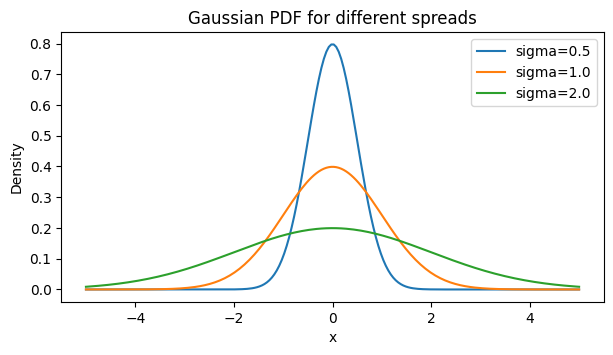

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

x = np.linspace(-5, 5, 200)

fig, ax = plt.subplots(figsize=(7, 3.5))

for sigma in [0.5, 1.0, 2.0]:
    ax.plot(
        x,
        stats.norm(loc=0, scale=sigma).pdf(x),
        label=f'sigma={sigma}'
    )

ax.set_title('Gaussian PDF for different spreads')
ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.legend()
plt.show()


Poisson(2) mean ~ 1.975 (true 2)


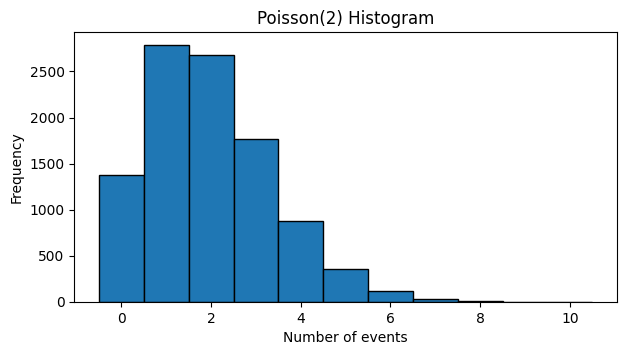

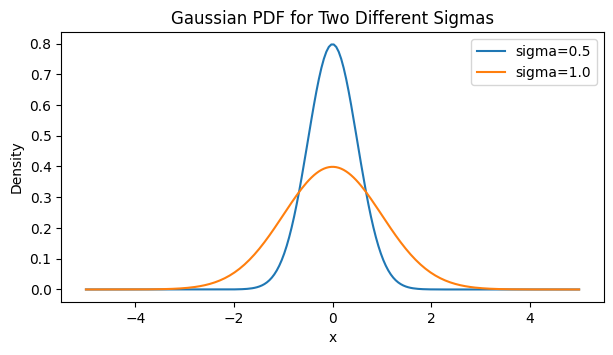

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Poisson(mu=2) samples + mean
pois = stats.poisson(mu=2).rvs(size=10_000)
print("Poisson(2) mean ~", round(pois.mean(), 3), "(true 2)")


plt.figure(figsize=(7, 3.5))
plt.hist(pois, bins=np.arange(-0.5, pois.max() + 1.5, 1), edgecolor='black')
plt.title("Poisson(2) Histogram")
plt.xlabel("Number of events")
plt.ylabel("Frequency")
plt.show()
x = np.linspace(-5, 5, 200)

plt.figure(figsize=(7, 3.5))

for sigma in [0.5, 1.0]:
    plt.plot(
        x,
        stats.norm(loc=0, scale=sigma).pdf(x),
        label=f"sigma={sigma}"
    )

plt.title("Gaussian PDF for Two Different Sigmas")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()


In [21]:
from scipy.stats import entropy

fair   = [0.5, 0.5]
biased = [0.9, 0.1]
certain= [1.0, 0.0]
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')

Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [22]:
P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])

print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')

D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [23]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


In [24]:
import numpy as np
from scipy import stats


p4 = [1/4] * 4
p6 = [1/6] * 6

H4 = stats.entropy(p4, base=2)
H6 = stats.entropy(p6, base=2)

print("Entropy of 4-sided die:", round(H4, 3), "bits")
print("Entropy of 6-sided die:", round(H6, 3), "bits")
P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])

KL = stats.entropy(P, Q)
print("KL divergence D(P || Q):", round(KL, 3), "nats")


print("Most informative: petal length")
print("Least informative: sepal width")


Entropy of 4-sided die: 2.0 bits
Entropy of 6-sided die: 2.585 bits
KL divergence D(P || Q): 0.082 nats
Most informative: petal length
Least informative: sepal width
